# EDA — Bagian 1: Eksplorasi Data General

**Tujuan:** Memotret bentuk dan karakteristik dasar dataset apa adanya, tanpa mengubah satu baris pun.

> Notebook ini hanya **mengukur**. Tidak ada data yang dimodifikasi, disimpan, atau dibuang di sini.  
> Seluruh keputusan didokumentasikan di `EDA_PLAN.md` dan dieksekusi di `02_preprocessing.ipynb`.

**Random seed:** `42`

In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
DATA_PATH = Path('../dataset/raw/data_labeling.csv')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

Path('../results/figures').mkdir(parents=True, exist_ok=True)

---
## 1.0 Load Data

In [2]:
df = pd.read_csv(DATA_PATH, index_col=0)
print(f'Shape: {df.shape[0]:,} baris x {df.shape[1]} kolom')
df.head(3)

Shape: 14,237 baris x 11 kolom


,number,commentId,author,authorChannelId,textDisplay,textOriginal,likeCount,publishedAt,updatedAt,comment_id,label
0,1,UgwGCePK-opaSTp60494AaABAg.ALZeLIlFw1wALya3HLW348,@andiw_yt,UCy_4eeHHqPad6kIv0Ks2hbw,sudah habis masanya,sudah habis masanya,0,2025-08-18T15:23:53Z,2025-08-18T15:23:53Z,UgwGCePK-opaSTp60494AaABAg.ALZeLIlFw1wALya3HLW348,0
1,2,UgwFbJ1DGuPwCkk_Nbt4AaABAg.ALOQ91rJWfXALaBdWYhLAh,@Midone-w9c,UCtvlX20ymOmALM6PDMH9S4g,Srg hero pool luas coach nya lagi teliti di ba...,Srg hero pool luas coach nya lagi teliti di ba...,0,2025-08-09T04:00:00Z,2025-08-09T04:00:00Z,UgwFbJ1DGuPwCkk_Nbt4AaABAg.ALOQ91rJWfXALaBdWYhLAh,0
2,3,UgxYuOnKVrvEasBZ3mR4AaABAg,@jaajaa7057,UClSjjStQ6RwiRCthd9qYp9w,Gw ingat ayat keramat ini &quot;Di pulangkan o...,"Gw ingat ayat keramat ini ""Di pulangkan oleh t...",0,2025-08-27T01:55:49Z,2025-08-27T01:55:49Z,UgxYuOnKVrvEasBZ3mR4AaABAg,0


In [3]:
print('Tipe data tiap kolom:')
print(df.dtypes)
meta_cols = [c for c in df.columns if c not in ['textOriginal', 'label']]
print('\nKolom relevan : textOriginal, label')
print(f'Kolom metadata: {meta_cols}')

Tipe data tiap kolom:
number              int64
commentId          object
author             object
authorChannelId    object
textDisplay        object
textOriginal       object
likeCount           int64
publishedAt        object
updatedAt          object
comment_id         object
label               int64
dtype: object

Kolom relevan : textOriginal, label
Kolom metadata: ['number', 'commentId', 'author', 'authorChannelId', 'textDisplay', 'likeCount', 'publishedAt', 'updatedAt', 'comment_id']


---
## 1.1 Distribusi Label

  Label 0: 8,560 (60.13%)
  Label 1: 5,677 (39.87%)

Rasio imbalance: 1.51:1


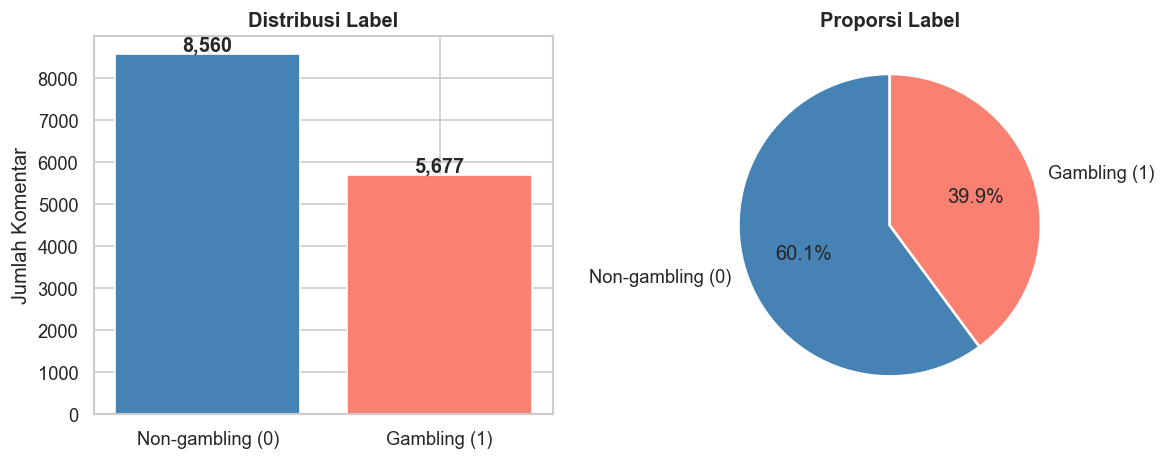

In [4]:
label_counts = df['label'].value_counts().sort_index()
label_pct    = df['label'].value_counts(normalize=True).sort_index() * 100

for lbl in label_counts.index:
    print(f'  Label {lbl}: {label_counts[lbl]:,} ({label_pct[lbl]:.2f}%)')
print(f'\nRasio imbalance: {label_counts.max() / label_counts.min():.2f}:1')

colors = ['steelblue', 'salmon']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Non-gambling (0)', 'Gambling (1)'], label_counts.values,
            color=colors, edgecolor='white')
axes[0].set_title('Distribusi Label', fontweight='bold')
axes[0].set_ylabel('Jumlah Komentar')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + label_counts.max() * 0.01, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(
    label_counts.values,
    labels=['Non-gambling (0)', 'Gambling (1)'],
    autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Proporsi Label', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/label_distribution.png', bbox_inches='tight')
plt.show()

**[ISIAN] Implikasi distribusi label:**

- Rasio imbalance: `___:1`
- Jika imbalance signifikan: F1-macro sebagai metrik utama (bukan accuracy); stratified split wajib; pertimbangkan class weight di loss
- Implikasi RM-c: FAISS index didominasi kelas mayoritas — efek pada distribusi k-NN perlu dimonitor saat evaluasi

---
## 1.2 Missing Values

In [5]:
print('=== Kolom kritis ===')
print(df[['textOriginal', 'label']].isnull().sum().rename('NaN count').to_string())

print('\n=== Semua kolom ===')
missing_all = df.isnull().sum()
if missing_all.sum() > 0:
    print(missing_all[missing_all > 0].rename('NaN count').to_string())
else:
    print('  Tidak ada missing value.')

=== Kolom kritis ===
textOriginal    10
label            0

=== Semua kolom ===
textOriginal    10


---
## 1.3 Duplikat

Dua jenis yang dibedakan (lihat `EDA_PLAN.md`):

- **(a) Duplikat `commentId`** — komentar terambil ganda dari YouTube Data API (artefak, low-stakes)
- **(b) Duplikat `textOriginal` exact** — teks identik di komentar berbeda — **sumber data leakage**
- **(c) Near-duplicate (estimasi upper bound)** — normalisasi ringan untuk gambaran skala, bukan deteksi eksak

In [6]:
n = len(df)

# (a) Duplikat commentId
dup_id = df.duplicated(subset='commentId', keep=False).sum()

# (b) Duplikat textOriginal exact
dup_text_rows = df.duplicated(subset='textOriginal', keep=False).sum()
dup_text_drop = df.duplicated(subset='textOriginal', keep='first').sum()

# (c) Near-duplicate: normalisasi ringan sebagai estimasi upper bound
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

_norm = df['textOriginal'].fillna('').apply(normalize_text)
dup_near = _norm.duplicated(keep=False).sum()

print(f'Total baris                        : {n:,}')
print(f'(a) Duplikat commentId             : {dup_id:,} ({dup_id/n*100:.2f}%)')
print(f'(b) Duplikat textOriginal exact    : {dup_text_rows:,} baris ({dup_text_drop:,} akan dibuang)')
print(f'(c) Near-duplicate estimasi        : {dup_near:,} baris ({dup_near/n*100:.2f}%) — upper bound')

Total baris                        : 14,237
(a) Duplikat commentId             : 0 (0.00%)
(b) Duplikat textOriginal exact    : 5,922 baris (4,771 akan dibuang)
(c) Near-duplicate estimasi        : 6,368 baris (44.73%) — upper bound


In [7]:
# Distribusi label pada exact duplicate dan contoh teks
dup_mask = df.duplicated(subset='textOriginal', keep=False)
if dup_mask.sum() > 0:
    print('Distribusi label pada teks terduplikat:')
    print(df[dup_mask]['label'].value_counts().to_string())
    print('\nContoh (maks. 5) teks terduplikat:')
    shown = 0
    for txt, grp in df[dup_mask].groupby('textOriginal'):
        if shown >= 5:
            break
        labels = grp['label'].tolist()
        print(f'  [{len(grp)}x label={labels}] {str(txt)[:120]}')
        shown += 1
else:
    print('Tidak ada duplikat exact pada textOriginal.')

Distribusi label pada teks terduplikat:
label
1    4850
0    1072

Contoh (maks. 5) teks terduplikat:
  [2x label=[0, 0]] #STOPJUDI
  [2x label=[0, 0]] #STOPJUDOL
  [2x label=[0, 0]] .
  [3x label=[1, 1, 1]] 00:30 Wow,🌍ℙℝ𝕆𝔹𝔼𝕋855🌍beda banget! Ceritanya mengalir, visualnya kece, dan kemenangannya bikin hati melayang. Harus coba!
  [4x label=[1, 1, 1, 1]] 00:37 Gila,🀄ℙℝ𝕆𝔹𝔼𝕋855🀄bikin nagih parah! Ceritanya dalem, visualnya ciamik, kemenangannya bikin shock senang. Wajib coba


---
## 1.4 Statistik Panjang Teks

Dua dimensi: **karakter** (panjang teks mentah) dan **token IndoBERT** (relevan untuk keputusan `max_length`).

=== Statistik panjang karakter per kelas ===
        count  mean   std   min   25%   50%   75%    max
label                                                   
0      8560.0  41.5  50.7   0.0  13.0  28.0  51.0  886.0
1      5677.0  61.7  28.5  11.0  46.0  58.0  69.0  311.0

=== Statistik panjang kata per kelas ===
        count  mean  std  min  25%  50%   75%    max
label                                               
0      8560.0   7.3  8.5  0.0  2.0  5.0   9.0  160.0
1      5677.0   8.9  4.3  2.0  6.0  8.0  10.0   47.0


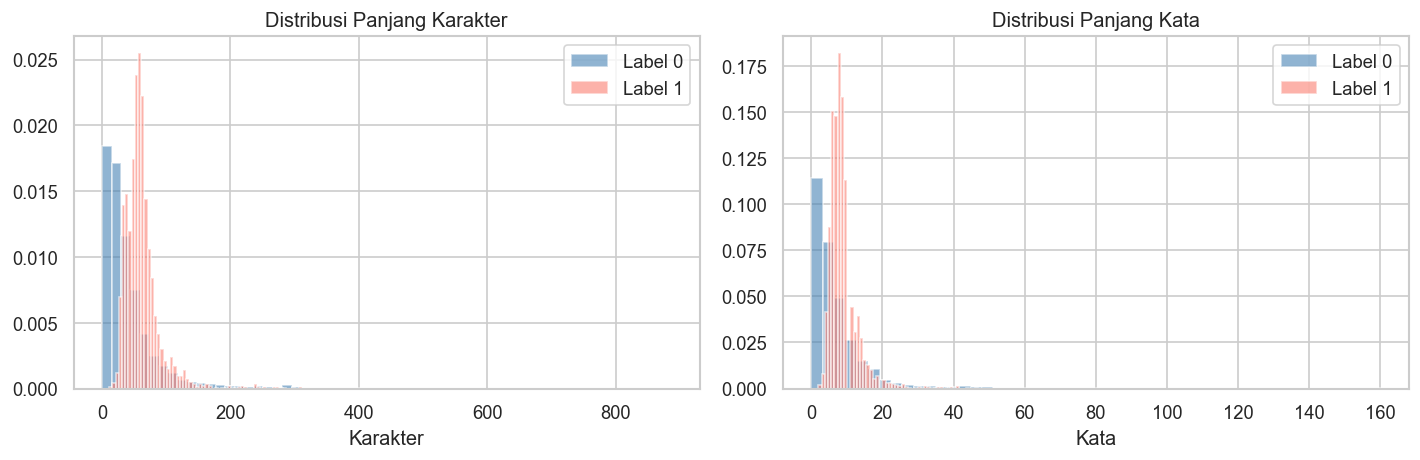

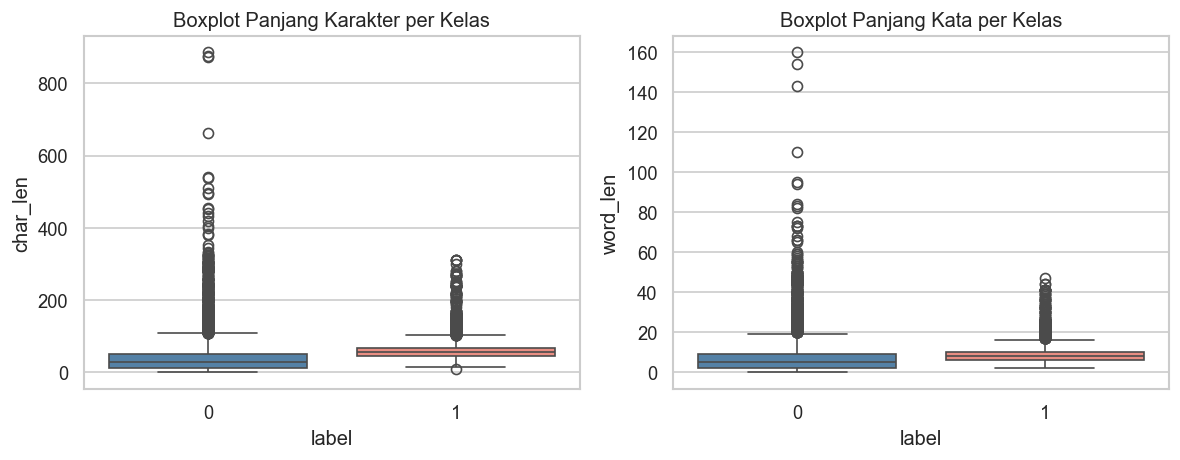

In [8]:
df['char_len'] = df['textOriginal'].fillna('').str.len()
df['word_len'] = df['textOriginal'].fillna('').str.split().str.len()

print('=== Statistik panjang karakter per kelas ===')
print(df.groupby('label')['char_len'].describe().round(1).to_string())
print('\n=== Statistik panjang kata per kelas ===')
print(df.groupby('label')['word_len'].describe().round(1).to_string())

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for lbl, color in [(0, 'steelblue'), (1, 'salmon')]:
    data = df[df['label'] == lbl]
    axes[0].hist(data['char_len'], bins=60, alpha=0.6, color=color, label=f'Label {lbl}', density=True)
    axes[1].hist(data['word_len'], bins=50, alpha=0.6, color=color, label=f'Label {lbl}', density=True)
axes[0].set_title('Distribusi Panjang Karakter'); axes[0].set_xlabel('Karakter'); axes[0].legend()
axes[1].set_title('Distribusi Panjang Kata');     axes[1].set_xlabel('Kata');     axes[1].legend()
plt.tight_layout()
plt.savefig('../results/figures/text_length_histogram.png', bbox_inches='tight')
plt.show()

# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, x='label', y='char_len', ax=axes[0], palette=['steelblue', 'salmon'])
sns.boxplot(data=df, x='label', y='word_len', ax=axes[1], palette=['steelblue', 'salmon'])
axes[0].set_title('Boxplot Panjang Karakter per Kelas')
axes[1].set_title('Boxplot Panjang Kata per Kelas')
plt.tight_layout()
plt.savefig('../results/figures/text_length_boxplot.png', bbox_inches='tight')
plt.show()

Memuat tokenizer indobert-base-p2...


do_lower_case = True  <- penting untuk keputusan case folding
Menghitung panjang token (tanpa truncation) — harap tunggu...



=== Statistik panjang token per kelas ===
        count  mean   std  min   25%   50%   75%    max
label                                                  
0      8560.0  12.1  12.1  2.0   5.0   9.0  14.0  254.0
1      5677.0  14.9   6.9  4.0  11.0  13.0  17.0   80.0

Persentil panjang token (semua kelas):
  P 50: 11 token
  P 75: 16 token
  P 90: 23 token
  P 95: 32 token
  P 99: 54 token
  P100: 254 token

Persentase komentar yang melebihi max_length kandidat:
  >  64 token: 0.44%
  > 128 token: 0.04%
  > 256 token: 0.00%
  > 512 token: 0.00%


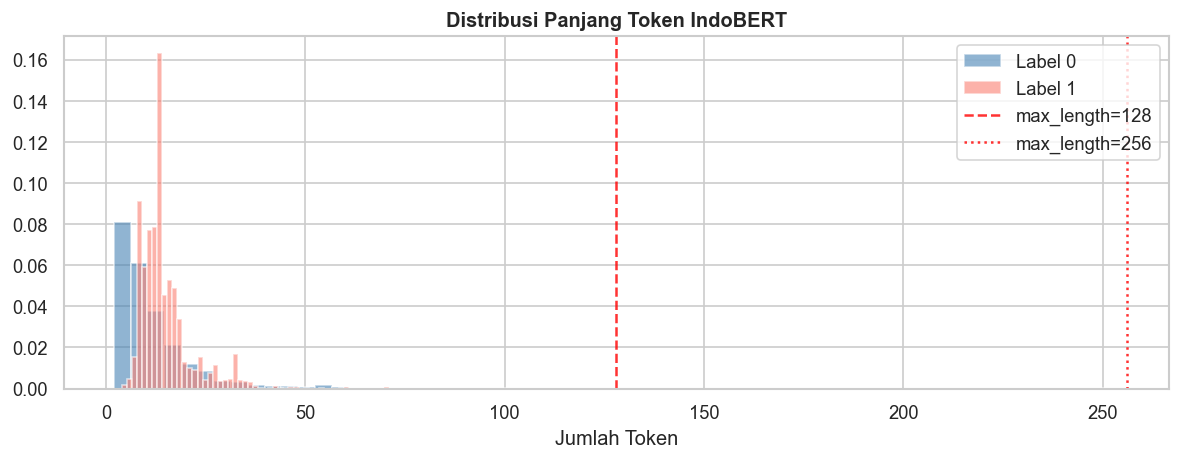

In [9]:
try:
    from transformers import AutoTokenizer

    print('Memuat tokenizer indobert-base-p2...')
    tokenizer = AutoTokenizer.from_pretrained('indobenchmark/indobert-base-p2')
    print(f'do_lower_case = {tokenizer.do_lower_case}  <- penting untuk keputusan case folding')

    print('Menghitung panjang token (tanpa truncation) — harap tunggu...')
    df['token_len'] = df['textOriginal'].fillna('').apply(
        lambda x: len(tokenizer.encode(x, add_special_tokens=True, truncation=False))
    )

    print('\n=== Statistik panjang token per kelas ===')
    print(df.groupby('label')['token_len'].describe().round(1).to_string())

    print('\nPersentil panjang token (semua kelas):')
    for p in [50, 75, 90, 95, 99, 100]:
        val = np.percentile(df['token_len'], p)
        print(f'  P{p:3d}: {val:.0f} token')

    print('\nPersentase komentar yang melebihi max_length kandidat:')
    for max_len in [64, 128, 256, 512]:
        pct = (df['token_len'] > max_len).mean() * 100
        print(f'  > {max_len:3d} token: {pct:.2f}%')

    fig, ax = plt.subplots(figsize=(10, 4))
    for lbl, color in [(0, 'steelblue'), (1, 'salmon')]:
        ax.hist(df[df['label'] == lbl]['token_len'], bins=60, alpha=0.6,
                color=color, label=f'Label {lbl}', density=True)
    for max_len, ls in [(128, '--'), (256, ':')]:
        ax.axvline(max_len, color='red', linestyle=ls, alpha=0.8, label=f'max_length={max_len}')
    ax.set_title('Distribusi Panjang Token IndoBERT', fontweight='bold')
    ax.set_xlabel('Jumlah Token')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../results/figures/token_length_distribution.png', bbox_inches='tight')
    plt.show()

except ImportError:
    print('transformers belum terinstall. Jalankan: pip install transformers')
    print('Cell ini perlu dijalankan ulang setelah install.')

**[ISIAN] Keputusan `max_length` (isi setelah cell tokenizer di atas dijalankan):**

| Metrik | Nilai |
|--------|-------|
| `do_lower_case` tokenizer | Iya|
| P95 token length | 32 Token |
| P99 token length | 54 Token|
| % komentar > 128 token | 0.04% |
| **Keputusan `max_length`** | 128 Token |
| Alasan | Komentar dengan panjang token 128 hanya mencapai 0.04% saja |

---
## 1.5 Distribusi Temporal

Rentang waktu : 2025-07-31 s/d 2025-10-01
Durasi        : 62 hari


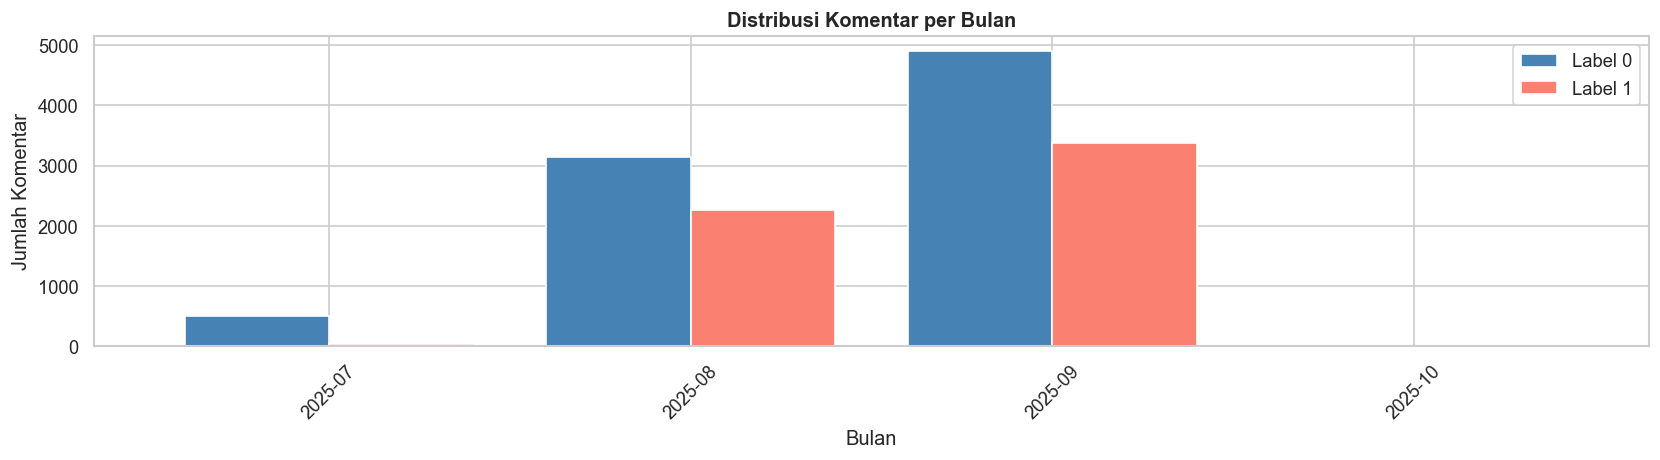

In [10]:
df['publishedAt'] = pd.to_datetime(df['publishedAt'], utc=True)
df['month'] = df['publishedAt'].dt.to_period('M')

t_min = df['publishedAt'].min().date()
t_max = df['publishedAt'].max().date()
t_dur = (df['publishedAt'].max() - df['publishedAt'].min()).days
print(f'Rentang waktu : {t_min} s/d {t_max}')
print(f'Durasi        : {t_dur} hari')

monthly = df.groupby(['month', 'label']).size().unstack(fill_value=0)
monthly.columns = [f'Label {c}' for c in monthly.columns]

ax = monthly.plot(kind='bar', figsize=(14, 4), color=['steelblue', 'salmon'],
                  edgecolor='white', width=0.8)
ax.set_title('Distribusi Komentar per Bulan', fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Komentar')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../results/figures/temporal_distribution.png', bbox_inches='tight')
plt.show()

---
## 1.6 Sampel Inspeksi & Audit Label

~15 sampel acak per kelas untuk:
1. Membangun intuisi tentang konten komentar nyata
2. Spot-check kualitas label — cari pola ambiguitas sistematis

> **Hal yang dicari:** komentar yang *menyebut* judi tapi *mengkritiknya* (dilabeli apa?), komentar sangat singkat, obfuskasi (`sl0t`, `g4cor`, `j*di`).

In [11]:
print('=== SAMPEL LABEL 0 — Non-gambling ===')
for idx, row in df[df['label'] == 0].sample(15, random_state=RANDOM_SEED).iterrows():
    text = str(row['textOriginal'])[:250].replace(chr(10), ' ')
    print(f'  [{idx:5d}] {text}')
    print()

=== SAMPEL LABEL 0 — Non-gambling ===
  [10296] Allo

  [ 5680] udah beberapa hari gk live kau turun ke jalan lagi kah ketua

  [ 5647] mantap ketuaaa

  [14171] ​@super_gambrisraja goa kalo kini

  [ 3123] Enak enak tidur tidur, live ketua

  [ 9777] P

  [ 2585] Sebelum ribuan 😂

  [ 9606] TOP UP DIAMOND TERBAIK CUMA DI OURASTORE.COM!

  [ 5124] Udah tahu ada balerick malah di dekati 😂😂😂😂 kena pasif nya terus col col

  [11194] Rotasi kau jelek kali ketua, sama kayak kau jelek nya ketua...Mending main brawl aja kau ketua😂

  [  712] GUE MALAH KETAWA LIAT LORD BKENT MARAH MARAH😂😂... gue g liat live nya, gue lebih suka nonton uploadan lu bang

  [ 1800] terhibur banget 🗿

  [13791] Udah lah bosen gua...

  [10317] Emg bagus cuman untuk draft pasti kurang

  [13611] Badut oh badut😂😂😂



In [12]:
print('=== SAMPEL LABEL 1 — Gambling ===')
for idx, row in df[df['label'] == 1].sample(15, random_state=RANDOM_SEED).iterrows():
    text = str(row['textOriginal'])[:250].replace(chr(10), ' ')
    print(f'  [{idx:5d}] {text}')
    print()

=== SAMPEL LABEL 1 — Gambling ===
  [ 4879] Terpopuler Ｇ ＡＲ ＵＤ Ａ Ｈ ０ Ｋ ｌ Spesial Kemerdekaan Berbagi Kemenangan

  [ 4082] Teman yang jarang update pun pasang story tentang 🄿🅄🄻🄰🅄🅆🄸🄽.

  [ 6587] Sumpah 5-8 angka kesukaan ku pisan, 🤎𝐏𝐑𝐎𝐁𝐄𝐓 𝟖𝟓𝟓🤎

  [ 8684] Temen gue ngedm, “Pᴜʟᴀᴜᴡɪɴ itu makanan kek, atau apa sih bro?”

  [11848] Pulau777 selalu kasih kejutan 🎁

  [ 5770] Bahkan di caption foto liburan pun banyak yang tulis 🄿🅄🄻🄰🅄🅆🄸🄽.

  [10909] 🌴 Pulau777, bikin mood makin happy 😍

  [11019] Gak ada yg bisa ngalahin Kita boleh mencoba tapi kalau dah sayang mau bagaimana , Dari awal saya di kasih mulu jadi saya memilih🀄ℙℝ𝕆𝔹𝔼𝕋855🀄

  [11906] Dengerin podcast santai, nama 𝑷𝒖𝒍𝒂𝒖𝒘𝒊𝒏 disebut-sebut terus.

  [ 3417] Ngobrol santai di tongkrongan pasti ada nyelip kata ＰＵＬＡＵＷＩＮ.

  [11420] Setiap hari selalu ada kejutan di 𝐃⁠​𝐎‍𝐑⁠⁠𝐀⁠‍𝟕‍⁠𝟕! Bikin penasaran!

  [10809] Desain grafis di kampus banyak yang pakai font ✧𝙋𝙐𝙇𝘼𝙐𝙒𝙄𝙉✧ sebagai contoh.

  [ 7300] 𝐃𝐎𝐑𝐀𝟕𝟕 emang juara maxwin

  [ 7684] Ada mural k

**[ISIAN] Catatan Audit Label:**

| Observasi | Detail |
|-----------|--------|
| Ciri khas label 1 yang tampak | Nama merek judi diobfuskasi dengan teknik Unicode beragam: fullwidth, mathematical bold/italic, negative squared, small caps, fraktur/double-struck, dan variation selector. Emoji dekoratif dipakai sebagai pembungkus nama. Merek yang teridentifikasi: PULAUWIN, DORA77, PROBET855, GARUDAH0Kl.  |
| Kasus ambigu yang ditemukan |[10809] & [7684] — merek diframe sebagai font desain dan mural kampus. [8684] — strategi "pura-pura tidak tahu" untuk menyebut nama merek. [4879] — nama merek kurang populer, perlu verifikasi eksternal. |
| Konsistensi label secara umum | Konsisten — semua 15 komentar mengandung nama merek judi. [4082] vs [5770] berstruktur sangat mirip, perlu cek near-duplicate sebelum split train/val. |
| Indeks komentar perlu periksa ulang | [10809], [7684], [8684] — framing menyesatkan, rawan salah label. [4879] — nama merek tidak familiar. [4082] & [5770] — potensi duplikat. |

---
## Ringkasan Bagian 1

Isi setelah seluruh cell dijalankan. Tabel ini menjadi input untuk melengkapi Bagian 2 dan 3 di `EDA_PLAN.md`.

| Metrik | Nilai |
|--------|-------|
| Total baris | 14,237 |
| Distribusi label (0 / 1) | 8,560 / 5,677 |
| Rasio imbalance | 1.51:1 |
| Missing `textOriginal` | 10 |
| Missing `label` | 0 |
| Dup `commentId` | 0 |
| Dup `textOriginal` exact | 5,922 |
| Near-duplicate estimasi | 6,368 |
| Median token length (label 0 / 1) | 9.0 / 13.0 |
| P99 token length | 54 |
| % komentar > 128 token | 0.04% |
| `do_lower_case` tokenizer | Iya |
| Rentang waktu data | 2025-07-31 s/d 2025-10-01 |

---
# Bagian 1 — Susulan: Pengukuran Deskriptif Tambahan (⏳)

Melengkapi Bagian 1 dengan lima analisis **murni komputasi** dari data mentah (tidak butuh keputusan transformasi apa pun lebih dulu). Semua bersifat **deskriptif** — tidak ada baris yang diubah/dibuang. Hasil menjadi basis pengujian Bagian 2 & keputusan Bagian 3.

> Catatan: seluruh sel di bawah bekerja pada `valid = df` non-missing. Kolom `char_len`/`word_len`/`token_len` sudah dihitung di sel 1.4.

## 1.7 Distribusi Kelas Pasti Pasca-Dedup Exact

Verifikasi estimasi §9.1 laporan (kelas 1 diperkirakan anjlok, rasio membalik). Dihitung langsung: `drop_duplicates(subset='textOriginal')` lalu hitung ulang distribusi label.

In [13]:
valid = df[df['textOriginal'].notna() & df['label'].notna()].copy()
raw = valid['label'].value_counts().sort_index()

dedup = valid.drop_duplicates(subset='textOriginal', keep='first')
vc = dedup['label'].value_counts().sort_index()
n0, n1 = int(vc.get(0, 0)), int(vc.get(1, 0))

print(f'Baris valid (non-missing)        : {len(valid):,}')
print(f'Setelah dedup exact textOriginal : {len(dedup):,}')
print(f'  Label 0 : {n0:,} ({n0/len(dedup)*100:.2f}%)')
print(f'  Label 1 : {n1:,} ({n1/len(dedup)*100:.2f}%)')
print(f'  Rasio   : {max(n0,n1)/min(n0,n1):.2f}:1 (mayoritas kelas {0 if n0>n1 else 1})')
print(f'\nPerubahan vs raw (valid):')
print(f'  L1: {int(raw.get(1,0)):,} -> {n1:,}  (turun {int(raw.get(1,0))-n1:,})')
print(f'  L0: {int(raw.get(0,0)):,} -> {n0:,}  (turun {int(raw.get(0,0))-n0:,})')
print(f'\nKelayakan kelas 1 pasca-split 70/15/15:')
print(f'  train ~{int(n1*0.70):,} | val ~{int(n1*0.15):,} | test ~{int(n1*0.15):,}')

Baris valid (non-missing)        : 14,227
Setelah dedup exact textOriginal : 9,465
  Label 0 : 7,702 (81.37%)
  Label 1 : 1,763 (18.63%)
  Rasio   : 4.37:1 (mayoritas kelas 0)

Perubahan vs raw (valid):
  L1: 5,677 -> 1,763  (turun 3,914)
  L0: 8,550 -> 7,702  (turun 848)

Kelayakan kelas 1 pasca-split 70/15/15:
  train ~1,234 | val ~264 | test ~264


**Temuan 1.7:** Estimasi §9.1 **terkonfirmasi**. Kelas 1 anjlok dari 5.677 → **1.763** (turun 3.914), kelas 0 dari 8.550 → **7.702**. Rasio membalik dari 1,51:1 (mentah) menjadi **4,37:1** (kelas 0 dominan). Kelas 1 menyisakan **~1.234 sampel train** — memadai untuk RM-a, tipis-tapi-cukup untuk RM-b/RM-c. Menguatkan **F1-macro + stratified split + class weight** (ditetapkan final di Bagian 3).

## 1.8 Grup Duplikat Exact Ber-konflik Label

Deteksi (bukan keputusan): grup `textOriginal` identik yang memuat >1 label unik. Aturan penanganan (assign label 1) sudah dikunci di Bagian 3; di sini hanya menghitung skalanya.

In [14]:
grp = valid.groupby('textOriginal')['label'].agg(['nunique', 'count'])
conflict = grp[grp['nunique'] > 1]
print(f'Grup teks duplikat exact ber-konflik label : {len(conflict):,} grup')
print(f'Baris terdampak                            : {int(conflict["count"].sum()):,}')

if len(conflict):
    print('\nSemua grup konflik:')
    for txt, sub in valid[valid['textOriginal'].isin(conflict.index)].groupby('textOriginal'):
        dist = sub['label'].value_counts().to_dict()
        print(f'  [{len(sub)}x label={dist}] {str(txt)[:80]}')
print('\nCatatan: penanganan default = assign label 1 (dikunci di Bagian 3). Di sini hanya deteksi jumlah.')

Grup teks duplikat exact ber-konflik label : 3 grup
Baris terdampak                            : 32

Semua grup konflik:
  [17x label={1: 16, 0: 1}] Aku pertama depo jp diGaruda-Ho ki😚
  [4x label={1: 3, 0: 1}] Ga Ruda Ho ki-gokil banget pecah terus ga sia sia anjaay🔥
  [11x label={1: 10, 0: 1}] Gasskuyy dari bang toing katanya,Ga ruda-Ho ki-Badai petir🔥🔥

Catatan: penanganan default = assign label 1 (dikunci di Bagian 3). Di sini hanya deteksi jumlah.


**Temuan 1.8:** Hanya **3 grup** konflik (**32 baris**) — seluruhnya varian brand *"Garuda-Hoki"*. Di tiap grup, mayoritas berlabel 1 dengan **1 baris label 0** menyimpang (kemungkinan salah-label anotator). Skala sangat kecil (0,2%), dan aturan **assign label 1** sejalan dengan mayoritas → aman dan tidak mengubah distribusi secara berarti.

## 1.9 Komentar Sangat Pendek per Label

Temuan Bagian 1: komentar pendek kelas 0 mencakup kampanye anti-judi valid (`#STOPJUDOL`) **dan** noise (`.`, `P`). Threshold panjang tidak boleh berdiri sendiri — dibaca per label & per isi (flag alfanumerik).

In [15]:
print('=== Komentar pendek per panjang KARAKTER ===')
print(f'  {"Threshold":12s} {"n":>7s} {"pct":>7s} {"L0":>7s} {"L1":>7s}')
print('  ' + '-' * 44)
for t in [1, 2, 3, 5, 10]:
    m = valid['char_len'] <= t
    print(f'  <= {t:<2d} char   {int(m.sum()):7,} {m.mean()*100:6.2f}% '
          f'{int((m & (valid.label==0)).sum()):7,} {int((m & (valid.label==1)).sum()):7,}')

print('\n=== Komentar pendek per panjang KATA ===')
print(f'  {"Threshold":12s} {"n":>7s} {"pct":>7s} {"L0":>7s} {"L1":>7s}')
print('  ' + '-' * 44)
for t in [0, 1, 2, 3, 5]:
    m = valid['word_len'] <= t
    print(f'  <= {t:<2d} kata   {int(m.sum()):7,} {m.mean()*100:6.2f}% '
          f'{int((m & (valid.label==0)).sum()):7,} {int((m & (valid.label==1)).sum()):7,}')

# Kampanye vs noise pada komentar pendek kelas 0
short0 = valid[(valid.word_len <= 2) & (valid.label == 0)].copy()
short0['has_alnum'] = short0['textOriginal'].str.contains(r'[A-Za-z0-9]', regex=True, na=False)
print(f'\nKomentar <=2 kata KELAS 0: {len(short0):,} | mengandung alfanumerik: {int(short0.has_alnum.sum()):,} '
      f'| emoji/simbol murni: {int((~short0.has_alnum).sum()):,}')

camp = valid[valid['textOriginal'].str.contains(r'stop\s*jud', case=False, na=False, regex=True)]
print(f'\nKomentar kampanye "stopjud*": {len(camp):,} (L0={int((camp.label==0).sum())}, L1={int((camp.label==1).sum())}) '
      f'| di antaranya <=2 kata: {int((camp.word_len<=2).sum())}')
print('Contoh komentar <=2 kata KELAS 0 (maks 15):')
for idx, row in short0.head(15).iterrows():
    print(f'  [{idx:5d}|{int(row.word_len)}k] {str(row.textOriginal)[:55]}')

=== Komentar pendek per panjang KARAKTER ===
  Threshold          n     pct      L0      L1
  --------------------------------------------
  <= 1  char       184   1.29%     184       0
  <= 2  char       306   2.15%     306       0
  <= 3  char       472   3.32%     472       0
  <= 5  char       809   5.69%     809       0
  <= 10 char     1,587  11.15%   1,587       0

=== Komentar pendek per panjang KATA ===
  Threshold          n     pct      L0      L1
  --------------------------------------------
  <= 0  kata         0   0.00%       0       0
  <= 1  kata     1,256   8.83%   1,256       0
  <= 2  kata     2,262  15.90%   2,252      10
  <= 3  kata     3,168  22.27%   3,118      50
  <= 5  kata     5,370  37.75%   4,659     711

Komentar <=2 kata KELAS 0: 2,252 | mengandung alfanumerik: 1,894 | emoji/simbol murni: 358

Komentar kampanye "stopjud*": 5 (L0=5, L1=0) | di antaranya <=2 kata: 4
Contoh komentar <=2 kata KELAS 0 (maks 15):
  [   19|1k] Sekyss>sutsujin
  [   25|2k] Ahh 

**Temuan 1.9:** **Seluruh** komentar sangat pendek adalah **kelas 0** (≤5 karakter: 809 baris, L1=0; ≤2 kata: 2.262 baris, L1 hanya 10). Komentar judi praktis **tidak pernah** sangat pendek — butuh ruang untuk menampilkan brand. Kampanye `stopjud*` hanya **5 komentar** (semua L0, 4 di antaranya ≤2 kata). Implikasi untuk Bagian 3: filter panjang-saja hanya akan membuang kelas 0 dan berisiko menghapus kampanye valid → keputusan filtering pendek harus hati-hati.

## 1.10 Proporsi Komentar Non-Indonesia

Deteksi bahasa ringan (`langdetect`) langsung dari teks mentah. **Batasan scope** (sesuai `EDA_PLAN.md`): berhenti di deteksi sederhana — bukan language-model berat.

In [16]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = RANDOM_SEED

def detect_lang(text):
    try:
        return detect(str(text))
    except Exception:
        return 'unknown'

print('Mendeteksi bahasa (teks mentah) — harap tunggu...')
langs = valid['textOriginal'].apply(detect_lang)

print('\nDistribusi bahasa (top 10):')
print(langs.value_counts().head(10).to_string())

non_id = langs != 'id'
non_id_known = ~langs.isin(['id', 'unknown'])
print(f'\nNon-Indonesia (termasuk unknown) : {int(non_id.sum()):,} ({non_id.mean()*100:.2f}%)')
print(f'Non-Indonesia (bahasa terdeteksi): {int(non_id_known.sum()):,} ({non_id_known.mean()*100:.2f}%)')
print(f'Unknown (gagal deteksi)          : {int((langs=="unknown").sum()):,}')

tmp = valid[non_id_known].copy(); tmp['lang'] = langs[non_id_known]
print('\nDistribusi label non-Indonesia (exclude unknown):')
print(tmp['label'].value_counts().to_string())
print('\nContoh (maks 12) — cek akurasi deteksi:')
for idx, row in tmp.head(12).iterrows():
    print(f'  [{idx}|{langs[idx]}|L{row.label}] {str(row.textOriginal)[:60]}')

Mendeteksi bahasa (teks mentah) — harap tunggu...



Distribusi bahasa (top 10):
textOriginal
id         10477
tl           733
unknown      455
en           304
sw           271
de           243
so           225
fi           163
et           148
it           110

Non-Indonesia (termasuk unknown) : 3,750 (26.36%)
Non-Indonesia (bahasa terdeteksi): 3,295 (23.16%)
Unknown (gagal deteksi)          : 455

Distribusi label non-Indonesia (exclude unknown):
label
0    2864
1     431

Contoh (maks 12) — cek akurasi deteksi:
  [4|fi|L0] Ttoyyy ngapain taiii kntl
  [14|so|L0] ahahaha kasian sama fans lokal
  [15|en|L0] WOI MANA REACTION TIKTOK NYA..
  [17|en|L0] NT NT COMEBACK STRONGER 🤣🤡 Top 4 🇮🇩 server
  [18|fi|L0] lentoy ken 🎉🤣
  [19|fi|L0] Sekyss>sutsujin
  [26|tl|L0] Rrq pulang
  [32|pt|L0] Mampos😊
  [33|lt|L0] Kingdom nangis di pojokan😂
  [34|af|L0] Dyreen beban kek bot
  [38|en|L0] Tevospams bacot, team lu noh hina
  [40|en|L0] Rrq konon. Tim clowns 🤡 indog


**Temuan 1.10:** langdetect menandai **23,16%** "non-Indonesia" (excl. unknown), tapi angka ini **menyesatkan/over-estimate**: 733 baris "Tagalog (tl)" dan ratusan "sw/de/so/fi/et" hampir seluruhnya adalah **teks Indonesia informal/pendek yang salah-deteksi** (langdetect lemah pada slang & teks pendek). Contoh mengonfirmasi false-positive. Keputusan Bagian 3 mengarah ke **pertahankan** (drop berbasis bahasa tidak reliabel & berisiko membuang 431 L1 + 2.864 L0 valid).

## 1.11 Sampel Outlier Panjang Ekstrem (Top-20)

P99 token hanya 54 (Bagian 1), tapi ekor atas panjang **karakter** perlu ditinjau manual: konten valid (promosi/diskusi panjang) atau noise (spam pengulangan)?

In [17]:
print('Distribusi outlier panjang karakter:')
for p in [95, 99, 99.9]:
    v = np.percentile(valid['char_len'], p)
    m = valid['char_len'] > v
    print(f'  P{p:<5} > {v:6.0f} char: {int(m.sum()):4,} baris (L1: {int((m & (valid.label==1)).sum()):4,})')

print('\n=== Top-20 komentar terpanjang (karakter) ===')
for idx, row in valid.nlargest(20, 'char_len').iterrows():
    print(f'\n  [{idx}|L{row.label}|{int(row.char_len)} char|{int(row.word_len)} kata]')
    print(f'  {str(row.textOriginal)[:200]}')

Distribusi outlier panjang karakter:
  P95    >    115 char:  699 baris (L1:  228)
  P99    >    240 char:  142 baris (L1:   22)
  P99.9  >    404 char:   15 baris (L1:    0)

=== Top-20 komentar terpanjang (karakter) ===

  [1381|L0|886 char|143 kata]
  ​@FauziMuhammad-zh3kk Elu yang kocak, Skylar keluar gara2 dimarahin si AP tukang Baper, elo ga ngikutin drama2 si AP sih, makanya ga tau apa2, blom lagi gara2 itu istrinya si Dyfa juga ikutan dihina2,

  [739|L0|875 char|154 kata]
  Menurut gw aneh bgt, hazel itu jago klo diksh jam terbang bs kaya prime albert dlu. Roster season kemarin udh bgs cmn ganti ujin sama toy aj. Jdiin roster utama Skylar, hazel, idok, rinz, dyren.  Mlh 

  [13381|L0|873 char|160 kata]
  Rinz publik epic abadi sebenar.. Itu dia pilih spell purify.. Tpi ga ke pakai saat di ulti chou di yss dan di angkat zhuxin.. Mlh di simpan smpai mokad.. Kan bodoh gameplay kyk gitu.. Tpi giliran mahu

  [500|L0|662 char|110 kata]
  @bee7415 gmna ga badut itu rrq,  Mseries, ms

**Temuan 1.11:** Outlier panjang adalah **konten valid**, bukan noise. Top-20 terpanjang seluruhnya **kelas 0** berupa diskusi esports (MLBB) yang koheren; P99,9 (>404 char) pun 15 baris semuanya L0. Tidak ada pola spam-pengulangan di ekor atas. Keputusan Bagian 3 mengarah ke **pertahankan** — apalagi `max_length=128` token sudah menangani truncation.

---
## Ringkasan Bagian 1 — Susulan

| # | Analisis | Angka final |
|---|----------|-------------|
| 1.7 | Distribusi pasca-dedup exact | L0=7.702 / L1=1.763 — **rasio 4,37:1** (dari 1,51:1) |
| 1.8 | Grup duplikat konflik label | 3 grup / 32 baris (semua brand "Garuda-Hoki", mayoritas L1) |
| 1.9 | Komentar sangat pendek | ≤5 char: 809 (semua L0); ≤2 kata: 2.262 (L1=10); kampanye stopjud* = 5 |
| 1.10 | Non-Indonesia | 23,16% (over-estimate; false-positive langdetect dominan) |
| 1.11 | Outlier panjang | konten valid (diskusi esports L0); bukan noise |

> Seluruh angka bersifat **deskriptif**. Keputusan pakai/buang ada di **Bagian 3**.

---
# Bagian 2 — Uji Dampak Kandidat Transformasi

**Tujuan:** mengukur *efek* menerapkan sebuah kandidat transformasi **secara sementara** (in-memory, tidak dipersist), **sebelum** ada keputusan pakai/tidak. Beda dari Bagian 1 (mendeskripsikan data apa adanya) — di sini kita *mencoba* sesuatu lalu mengukur akibatnya.

| Kandidat | Cara uji | Metrik efek |
|---|---|---|
| **NFKC** | Terapkan sementara ke seluruh teks | (a) perubahan near-duplicate; (b) perubahan token `[UNK]` (p2), fokus kelas 1 |
| **Emoji removal** | Hapus emoji sementara | Berapa baris jadi string kosong |
| **Case folding** | — | Tidak diuji (`do_lower_case=True` → redundan) |

> **Belum ada keputusan** di bagian ini. Keputusan pakai/tidak baru di Bagian 3.

## 2.1 NFKC — Efek pada Deteksi Near-Duplicate

`normalize_nfkc` membuang karakter tak-terlihat lalu `unicodedata.normalize('NFKC', …)`. Bandingkan jumlah near-dup sebelum vs sesudah NFKC untuk mengonfirmasi caveat §5 laporan (44,73% dangkal adalah *lantai*).

In [18]:
import unicodedata

# Karakter tak-terlihat dibuang sebelum NFKC (sumber codepoint agar 100% ASCII)
_INVIS_CP = [0x200b, 0x200c, 0x200d, 0x200e, 0x200f, 0x2060, 0x00ad, *range(0xfe00, 0xfe10)]
_INVISIBLE = re.compile('[' + ''.join(chr(c) for c in _INVIS_CP) + ']')

# Buang karakter tak-terlihat lalu NFKC. Memetakan math bold/italic, fullwidth,
# double-struck, enclosed -> ASCII bila ada decomposition. Small caps TIDAK punya
# decomposition -> bertahan (didokumentasikan sebagai residual di Bagian 3).
def normalize_nfkc(text):
    return unicodedata.normalize('NFKC', _INVISIBLE.sub('', str(text)))

# NFKC lalu normalisasi dangkal (lower, hapus url/mention/punct, rapikan spasi).
def normalize_full(text):
    return normalize_text(normalize_nfkc(text))

keys = {
    'Mentah (exact)' : valid['textOriginal'],
    'Dangkal (lama)' : valid['textOriginal'].apply(normalize_text),
    'NFKC saja'      : valid['textOriginal'].apply(normalize_nfkc),
    'NFKC + dangkal' : valid['textOriginal'].apply(normalize_full),
}

print(f'=== Efek NFKC pada duplikasi (dari {len(valid):,} baris valid) ===\n')
print(f'  {"Kunci":18s} {"Terbuang":>9s} {"Unik":>8s} {"%dup":>8s}')
print('  ' + '-' * 45)
for name, key in keys.items():
    drop = int(key.duplicated(keep='first').sum())
    print(f'  {name:18s} {drop:9,} {int(key.nunique()):8,} {key.duplicated(keep=False).mean()*100:7.2f}%')

print('\n=== Distribusi kelas pasca-dedup per kunci ===\n')
print(f'  {"Kunci":18s} {"Total":>7s} {"L0":>7s} {"L1":>7s} {"Rasio":>8s}')
print('  ' + '-' * 50)
for name, key in keys.items():
    kept = valid.loc[~key.duplicated(keep='first')]
    a, b = int((kept.label==0).sum()), int((kept.label==1).sum())
    print(f'  {name:18s} {len(kept):7,} {a:7,} {b:7,} {a/b if b else 0:6.2f}:1')

print('\n=== Uji recovery pada sampel obfuskasi nyata (audit §8) ===')
for s in ['🤎𝐏𝐑𝐎𝐁𝐄𝐓 𝟖𝟓𝟓🤎', 'ＰＵＬＡＵＷＩＮ', 'ℙℝ𝕆𝔹𝔼𝕋855', 'Pᴜʟᴀᴜᴡɪɴ', '🄿🅄🄻🄰🅄🅆🄸🄽']:
    print(f'  {s!r} -> {normalize_nfkc(s)!r}')

=== Efek NFKC pada duplikasi (dari 14,227 baris valid) ===

  Kunci               Terbuang     Unik     %dup
  ---------------------------------------------
  Mentah (exact)         4,762    9,465   41.55%
  Dangkal (lama)         5,193    9,034   44.69%
  NFKC saja              4,815    9,412   41.84%
  NFKC + dangkal         5,253    8,974   44.84%

=== Distribusi kelas pasca-dedup per kunci ===

  Kunci                Total      L0      L1    Rasio
  --------------------------------------------------
  Mentah (exact)       9,465   7,702   1,763   4.37:1
  Dangkal (lama)       9,034   7,335   1,699   4.32:1
  NFKC saja            9,412   7,702   1,710   4.50:1
  NFKC + dangkal       8,974   7,335   1,639   4.48:1

=== Uji recovery pada sampel obfuskasi nyata (audit §8) ===
  '🤎𝐏𝐑𝐎𝐁𝐄𝐓 𝟖𝟓𝟓🤎' -> '🤎PROBET 855🤎'
  'ＰＵＬＡＵＷＩＮ' -> 'PULAUWIN'
  'ℙℝ𝕆𝔹𝔼𝕋855' -> 'PROBET855'
  'Pᴜʟᴀᴜᴡɪɴ' -> 'Pᴜʟᴀᴜᴡɪɴ'
  '🄿🅄🄻🄰🅄🅆🄸🄽' -> 'PULAUWIN'


**Efek 2.1:** NFKC menaikkan jumlah duplikat terdeteksi secara **modest tapi nyata** — kunci *exact* membuang 4.762 baris (41,55%), *NFKC saja* 4.815 (41,84%, **+53 baris**). Tambahan ini murni varian Unicode kelas 1 (`𝐏𝐑𝐎𝐁𝐄𝐓855`≡`ℙℝ𝕆𝔹𝔼𝕋855`). Uji recovery: **fullwidth, double-struck, enclosed → pulih ke ASCII** (`ＰＵＬＡＵＷＩＮ`→`PULAUWIN`, enclosed `🄿🅄…`→`PULAUWIN`); **small caps bertahan** (`Pᴜʟᴀᴜᴡɪɴ` tetap). Ini mengonfirmasi caveat §5: near-dup dangkal adalah lantai.

## 2.2 NFKC — Efek pada Tokenisasi `[UNK]` (p2)

**Pengukuran kunci.** Hitung token `[UNK]` sebelum vs sesudah NFKC memakai tokenizer **`indobert-base-p2`** (sel 1.4). Fokus kelas 1 (sarat obfuskasi Unicode).

In [19]:
tok = tokenizer  # p2, dimuat di sel 1.4

def unk_stats(series):
    total_unk = rows_unk = total_tok = 0
    for t in series:
        ids = tok.encode(str(t), add_special_tokens=False, truncation=True, max_length=256)
        u = sum(1 for i in ids if i == tok.unk_token_id)
        total_unk += u; total_tok += len(ids); rows_unk += (u > 0)
    return total_unk, rows_unk, total_tok

print(f'Tokenizer: indobert-base-p2 | unk_token={tok.unk_token} (id={tok.unk_token_id})\n')
print(f'  {"Scope":5s} {"n":>7s} | {"UNK before":>10s} {"%row":>6s} | {"UNK after":>10s} {"%row":>6s} | {"UNK turun":>10s}')
print('  ' + '-' * 78)
for scope, sub in [('ALL', valid), ('L1', valid[valid.label==1]), ('L0', valid[valid.label==0])]:
    bu, br, bt = unk_stats(sub['textOriginal'])
    au, ar, at = unk_stats(sub['textOriginal'].apply(normalize_nfkc))
    print(f'  {scope:5s} {len(sub):7,} | {bu:10,} {br/len(sub)*100:5.1f}% | '
          f'{au:10,} {ar/len(sub)*100:5.1f}% | {bu-au:6,} ({(bu-au)/bu*100 if bu else 0:4.1f}%)')

print('\n=== Contoh token brand yang pulih setelah NFKC ===')
for s in ['🤎𝐏𝐑𝐎𝐁𝐄𝐓 𝟖𝟓𝟓🤎', 'ＰＵＬＡＵＷＩＮ', 'ℙℝ𝕆𝔹𝔼𝕋855', 'Pᴜʟᴀᴜᴡɪɴ', '🄿🅄🄻🄰🅄🅆🄸🄽']:
    print(f'  {s}')
    print(f'    before: {tok.tokenize(s)}')
    print(f'    after : {tok.tokenize(normalize_nfkc(s))}')

Tokenizer: indobert-base-p2 | unk_token=[UNK] (id=1)

  Scope       n | UNK before   %row |  UNK after   %row |  UNK turun
  ------------------------------------------------------------------------------


  ALL    14,227 |     12,746  58.7% |      8,920  43.7% |  3,826 (30.0%)


  L1      5,677 |      9,160  90.5% |      5,489  53.6% |  3,671 (40.1%)


  L0      8,550 |      3,586  37.7% |      3,431  37.1% |    155 ( 4.3%)

=== Contoh token brand yang pulih setelah NFKC ===
  🤎𝐏𝐑𝐎𝐁𝐄𝐓 𝟖𝟓𝟓🤎
    before: ['[UNK]', '[UNK]']
    after : ['[UNK]', '[UNK]']
  ＰＵＬＡＵＷＩＮ
    before: ['[UNK]']
    after : ['pulau', '##win']
  ℙℝ𝕆𝔹𝔼𝕋855
    before: ['[UNK]']
    after : ['prob', '##et', '##85', '##5']
  Pᴜʟᴀᴜᴡɪɴ
    before: ['[UNK]']
    after : ['[UNK]']
  🄿🅄🄻🄰🅄🅆🄸🄽
    before: ['[UNK]']
    after : ['pulau', '##win']


**Efek 2.2 (decisive):** NFKC berdampak **besar** pada tokenisasi kelas 1. Baris kelas 1 yang mengandung ≥1 `[UNK]` turun dari **90,5% → 53,6%**; total `[UNK]` kelas 1 turun **40,1%** (9.160→5.489). Kelas 0 nyaris tak terpengaruh (turun 4,3%) — wajar, obfuskasi terkonsentrasi di kelas 1. Contoh: `ＰＵＬＡＵＷＩＮ` `[UNK]`→`pulau ##win`; enclosed `🄿🅄…`→`pulau ##win`; double-struck `ℙℝ𝕆𝔹𝔼𝕋855`→`prob ##et ##85 ##5`. Sisa `[UNK]`: small caps (`Pᴜʟᴀᴜᴡɪɴ`) & brand yang lengket dengan emoji. Inilah bukti terkuat untuk mengadopsi NFKC (diputus di Bagian 3).

## 2.3 Emoji Removal — Efek pada Baris Kosong

Hapus emoji sementara (regex Unicode-range; `emoji` lib tidak dipakai agar notebook bebas dependensi tambahan), hitung berapa baris jadi string kosong/whitespace — angka penentu apakah Bagian 3 perlu aturan drop tambahan.

In [20]:
# Regex rentang-Unicode emoji (blok utama). Dokumentasi: pendekatan ringan tanpa lib `emoji`.
EMOJI_RE = re.compile(
    '['
    '\U0001F300-\U0001FAFF'   # symbols & pictographs (+ supplemental, extended-A)
    '\U00002600-\U000027BF'   # misc symbols + dingbats
    '\U0001F1E6-\U0001F1FF'   # regional indicators
    '\U00002190-\U000021FF'   # arrows
    '\U00002B00-\U00002BFF'   # misc symbols & arrows
    '\U0000FE00-\U0000FE0F'   # variation selectors
    '\U0001F000-\U0001F0FF'   # mahjong / domino / cards
    '\U000024C2\U0000203C\U00002049'
    ']', flags=re.UNICODE)

def strip_emoji(t):
    return EMOJI_RE.sub('', str(t))

after = valid['textOriginal'].apply(strip_emoji).str.strip()
before_empty = valid['textOriginal'].fillna('').str.strip().eq('')
empty_after = after.eq('')
newly_empty = empty_after & ~before_empty

print(f'Baris kosong SEBELUM emoji removal        : {int(before_empty.sum()):,}')
print(f'Baris kosong SESUDAH emoji removal        : {int(empty_after.sum()):,}')
print(f'Baris BARU jadi kosong akibat emoji removal: {int(newly_empty.sum()):,}')
print(f'  L0 = {int((newly_empty & (valid.label==0)).sum()):,} | L1 = {int((newly_empty & (valid.label==1)).sum()):,}')
print('\nContoh baris jadi kosong (maks 15):')
for idx, row in valid[newly_empty].head(15).iterrows():
    print(f'  [{idx}|L{row.label}] {str(row.textOriginal)[:40]!r}')

Baris kosong SEBELUM emoji removal        : 0
Baris kosong SESUDAH emoji removal        : 353
Baris BARU jadi kosong akibat emoji removal: 353
  L0 = 353 | L1 = 0

Contoh baris jadi kosong (maks 15):
  [346|L0] '😂😂😂😂😂😂'
  [374|L0] '😂😂😂'
  [377|L0] '😂😅😂😅😅😅'
  [414|L0] '😂😂😂'
  [427|L0] '🎉🎉🎉🎉'
  [506|L0] '😂😂😂😂'
  [507|L0] '😂😂'
  [508|L0] '😂😂'
  [601|L0] '😅😅'
  [605|L0] '😂'
  [608|L0] '😂😂'
  [611|L0] '🙋'
  [620|L0] '😂😂'
  [624|L0] '☝️😁'
  [626|L0] '😂😂'


**Efek 2.3:** Menghapus emoji membuat **353 baris** menjadi kosong — **seluruhnya kelas 0**, berupa reaksi emoji-murni (`😂😂😂`, `🎉🎉🎉🎉`). Tidak ada satu pun kelas 1 yang bergantung sepenuhnya pada emoji. Artinya: emoji removal *sebagai transformasi wajib* justru menciptakan 353 baris yang harus di-drop (semua L0) — memaksa aturan filtering baru. Keputusan (Bagian 3) mengarah ke **tidak menghapus emoji** (tokenizer p2 sudah menanganinya).

## 2.4 Case Folding — Dilewati

**Tidak diuji.** `tokenizer.do_lower_case = True` (`indobert-base-p2`, sel 1.4) → IndoBERT sudah *uncased*. Lowercase manual dipastikan **redundan**. Dicatat "dilewati" di Bagian 3 tanpa pengukuran (sesuai `EDA_PLAN.md`).

---
## Ringkasan Efek Bagian 2 (before/after)

| Kandidat | Metrik | Before | After | Efek |
|---|---|---|---|---|
| NFKC | Near-dup terbuang (kunci NFKC vs exact) | 4.762 | 4.815 | +53 varian Unicode |
| NFKC | Baris L1 dgn `[UNK]` | 90,5% | 53,6% | **−36,9 pp** |
| NFKC | Total `[UNK]` L1 | 9.160 | 5.489 | **−40,1%** |
| NFKC | Total `[UNK]` semua | 12.746 | 8.920 | −30,0% |
| Emoji removal | Baris jadi kosong | 0 | 353 (semua L0) | butuh drop bila diterapkan |
| Case folding | — | — | — | dilewati (redundan) |

> **Belum ada keputusan** di sini. Angka efek di atas menjadi dasar keputusan Bagian 3.

---
# Bagian 3 — Keputusan Terpadu (Filtering + Transformasi)

Mengambil seluruh keputusan penyaringan baris & transformasi teks berdasarkan angka Bagian 1 (+susulan) & Bagian 2. Filtering dan transformasi digabung karena saling memengaruhi (loop, bukan garis lurus). Output: **spesifikasi final** untuk `02_preprocessing.ipynb` & bahan Bab 4.

> EDA **memutuskan**; eksekusi nyata (menulis file split) di `02_preprocessing.ipynb`.

## 3A. Prinsip Tetap (dari desain penelitian, tidak bergantung data)

- **Dedup pada data penuh sebelum split** (anti-leakage; kritis untuk RM-c/FAISS).
- Exact duplicate `textOriginal` → **drop** (keep first).
- Missing `textOriginal` atau `label` → **drop**.
- Konflik label pada grup duplikat exact → default **assign label 1** (§1.8: mayoritas memang L1).
- URL / mention / angka → ganti **placeholder** (`[URL]`, `[MENTION]`, `[NUM]`), **bukan** dihapus — sinyal kuat promosi judi.
- Obfuskasi residual (`sl0t`, `g4cor`, small caps sisa NFKC) → **dokumentasikan saja**, tidak membangun normalizer leetspeak (future work).
- Tokenisasi memakai WordPiece bawaan IndoBERT **p2** (bukan tokenisasi manual).

## 3B. Sudah Dikunci dari Bagian 1 (data-dependent, final)

- Drop **10** baris `textOriginal` kosong (§1.2).
- `max_length = 128` token (P99=54; truncation 0,04%) (§1.4).
- Case folding manual **dilewati** (`do_lower_case=True`) (§1.4 / §2.4).
- **Stratified split 70/15/15** (rasio kelas terjaga).

## 3C. Keputusan Data-Dependent — Final + Justifikasi

Setiap keputusan di bawah **ditetapkan final** berdasarkan angka Bagian 1-susulan & Bagian 2.

| # | Keputusan | Ketetapan | Justifikasi (angka) |
|---|-----------|-----------|---------------------|
| 1 | **NFKC (fondasi normalisasi)** | **DIPAKAI** — diterapkan sebelum dedup & tokenisasi | §2.2: baris L1 ber-`[UNK]` 90,5%→53,6% (`[UNK]` L1 −40,1%). Dampak besar, biaya 1 pemanggilan standar. |
| 2 | **Kunci dedup** | **NFKC-exact** (dedup pada teks ber-NFKC) | §2.1: menangkap +53 varian Unicode L1 (vektor leakage yang tepat untuk RM-c) tanpa over-merge. Full-norm (NFKC+dangkal, 5.253) di-*defer* karena lowercase/hapus-punct berisiko mengonflasi komentar pendek berbeda. |
| 3 | **Komentar terlalu pendek** | **TIDAK di-drop** (pertahankan) | §1.9: seluruh komentar pendek adalah L0; membuang hanya memangkas kelas mayoritas & berisiko menghapus kampanye `stopjud*` (5 komentar valid). Panjang bisa jadi sinyal lemah yang sah. |
| 4 | **Emoji** | **TIDAK dihapus** (dipertahankan) | §2.3: emoji removal menciptakan 353 baris kosong (semua L0) → memaksa drop tambахan; tokenizer p2 sudah menangani emoji. |
| 5 | **Komentar non-Indonesia** | **TIDAK di-drop** (pertahankan) | §1.10: langdetect over-estimate (23%; 733 "tl" = Indonesia salah-deteksi); drop tak reliabel & berisiko buang 431 L1 + 2.864 L0. Dicatat sebagai limitation. |
| 6 | **Outlier panjang ekstrem** | **TIDAK di-drop** (pertahankan) | §1.11: top-20 terpanjang = diskusi esports valid (L0), bukan noise; `max_length=128` sudah menangani truncation. |
| 7 | **Normalisasi slang/leetspeak** | **TIDAK dibangun** (future work) | §2.1: small caps & leetspeak residual bertahan setelah NFKC; robustness obfuskasi di luar scope, cukup didokumentasikan. |
| 8 | **Class weight pada loss** | **DIPERLUKAN** | §1.7: rasio pasca-dedup 4,37:1 (NFKC-key 4,50:1), dari 1,51:1 mentah. Kombinasi F1-macro + stratified + class weight. |

**Feasibility gate RM-b/RM-c:** kelas 1 pasca-dedup ~1.710 (NFKC-key) → train ~1.197. **Memadai** untuk RM-a (fine-tuning penuh) dan **cukup** untuk RM-b/RM-c (frozen encoder + head/retrieval butuh lebih sedikit data). **LOLOS**, dengan catatan kelas 1 tergolong tipis → pantau varians metrik & pertimbangkan class weight/threshold tuning.

## 3D. Tabel Before/After Count Final

Dihitung dengan kunci dedup terpilih (**NFKC-exact**). Semua keputusan lain = pertahankan → tidak mengurangi baris.

In [21]:
n_awal = len(df)
mask_missing = df['textOriginal'].isnull() | df['label'].isnull()
n_missing = int(mask_missing.sum())
v = df[~mask_missing].copy()

# Kunci dedup final = NFKC-exact
key_nfkc = v['textOriginal'].apply(normalize_nfkc)
dup_drop = int(key_nfkc.duplicated(keep='first').sum())
kept = v.loc[~key_nfkc.duplicated(keep='first')]
n_final = len(kept)
a, b = int((kept.label==0).sum()), int((kept.label==1).sum())

print('=== BEFORE/AFTER COUNT (kunci dedup = NFKC-exact) ===\n')
print(f'  Data awal                       : {n_awal:,}')
print(f'  - Missing textOriginal/label    : -{n_missing}')
print(f'  - Duplikat (NFKC-exact)         : -{dup_drop:,}')
print(f'  - Komentar pendek               : -0        (pertahankan, §3C-3)')
print(f'  - Non-Indonesia                 : -0        (pertahankan, §3C-5)')
print(f'  - Outlier panjang               : -0        (pertahankan, §3C-6)')
print(f'  - Emoji-empty                   : -0        (emoji tidak dihapus, §3C-4)')
print(f'  {"="*45}')
print(f'  Data final                      : {n_final:,}')
print()
print(f'  Distribusi kelas final : L0={a:,} ({a/n_final*100:.2f}%) | L1={b:,} ({b/n_final*100:.2f}%)')
print(f'  Rasio                  : {a/b:.2f}:1 (kelas 0 dominan)')
print(f'  Split 70/15/15 (L1)    : train~{int(b*0.70):,} | val~{int(b*0.15):,} | test~{int(b*0.15):,}')

# Perbandingan kunci alternatif (dokumentasi)
print('\n=== Perbandingan kunci dedup (dokumentasi) ===')
for name, key in [('exact', v['textOriginal']),
                  ('NFKC-exact (dipilih)', key_nfkc),
                  ('NFKC+dangkal (defer)', v['textOriginal'].apply(normalize_full))]:
    kk = v.loc[~key.duplicated(keep='first')]
    print(f'  {name:22s}: final={len(kk):,}  L0={int((kk.label==0).sum()):,}  L1={int((kk.label==1).sum()):,}')

=== BEFORE/AFTER COUNT (kunci dedup = NFKC-exact) ===

  Data awal                       : 14,237
  - Missing textOriginal/label    : -10
  - Duplikat (NFKC-exact)         : -4,815
  - Komentar pendek               : -0        (pertahankan, §3C-3)
  - Non-Indonesia                 : -0        (pertahankan, §3C-5)
  - Outlier panjang               : -0        (pertahankan, §3C-6)
  - Emoji-empty                   : -0        (emoji tidak dihapus, §3C-4)
  Data final                      : 9,412

  Distribusi kelas final : L0=7,702 (81.83%) | L1=1,710 (18.17%)
  Rasio                  : 4.50:1 (kelas 0 dominan)
  Split 70/15/15 (L1)    : train~1,197 | val~256 | test~256

=== Perbandingan kunci dedup (dokumentasi) ===


  exact                 : final=9,465  L0=7,702  L1=1,763
  NFKC-exact (dipilih)  : final=9,412  L0=7,702  L1=1,710
  NFKC+dangkal (defer)  : final=8,974  L0=7,335  L1=1,639


---
## Ringkasan Keputusan Bagian 3

Spesifikasi final untuk `02_preprocessing.ipynb` & bahan Bab 4.

| Kriteria | Keputusan | Threshold / Kunci | Baris Dibuang |
|----------|-----------|-------------------|---------------|
| Missing `textOriginal`/`label` | Drop | — | 10 |
| Normalisasi NFKC (fondasi) | **Dipakai** | `NFKC` sebelum dedup & tokenisasi | (bukan drop) |
| Dedup `textOriginal` | Drop (keep first) | **NFKC-exact** | 4.815 |
| Komentar terlalu pendek | **Pertahankan** | — | 0 |
| Komentar non-Indonesia | **Pertahankan** | — | 0 |
| Outlier panjang ekstrem | **Pertahankan** | — | 0 |
| Emoji | **Pertahankan** (tidak dihapus) | — | 0 |
| URL/mention/angka | Ganti placeholder | `[URL]`/`[MENTION]`/`[NUM]` | (transformasi) |
| Case folding | Dilewati | `do_lower_case=True` | — |
| **Total dibuang** | | | **4.825** |
| **Data final** | | | **9.412** |
| **Distribusi kelas final** | L0=7.702 (81,83%) / L1=1.710 (18,17%) | rasio **4,50:1** | |
| **Class weight** | **Diperlukan** | F1-macro + stratified + class weight | |
| **Feasibility RM-b/RM-c** | **Lolos** (L1 train ~1.197; tipis, dipantau) | | |

> Random seed **42** (sampling manual & split). Split stratified 70/15/15. Index FAISS RM-c dibangun **hanya dari train set**.